# AI-ML Assignment 8

## Lunar Lander Reinforcement Learning Agent Training

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Environment Setup

In [1]:
!pip install gymnasium[box2d]
!pip install swig
!pip install pygame

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 50.2 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
env = gym.make("LunarLander-v3")

print("Environment Created Successfully!")

Environment Created Successfully!


In [4]:
print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)

Action Space:
Discrete(4)


In [5]:
state, info = env.reset()

print("Initial State:")
print(state)

Initial State:
[-0.00163603  1.4198707  -0.16572537  0.39780858  0.00190252  0.0375393
  0.          0.        ]


In [6]:
state, info = env.reset()

for step in range(10):

    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Step {step+1}")
    print("Action:", action)
    print("Reward:", reward)

    if terminated or truncated:
        print("Episode Finished")
        break

Step 1
Action: 3
Reward: -0.6573187980032731
Step 2
Action: 3
Reward: -1.0011048258082542
Step 3
Action: 3
Reward: -1.123784924126112
Step 4
Action: 3
Reward: -1.5284070184851817
Step 5
Action: 2
Reward: -2.808073723745383
Step 6
Action: 1
Reward: 0.03225656268887292
Step 7
Action: 1
Reward: 0.19706187946087653
Step 8
Action: 0
Reward: -0.4493755390930403
Step 9
Action: 3
Reward: -1.6976000032008176
Step 10
Action: 2
Reward: -4.903357260737084


# Task 2: Agent Training

In [7]:
# Q-Learning Parameters

learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 500

# Initialize Q-table
q_table = {}

In [8]:
def get_state(state):
    # Round the continuous state values
    return tuple(np.round(state, 1))

In [9]:
episode_rewards = []

for episode in range(episodes):

    state, info = env.reset()
    state = get_state(state)

    total_reward = 0
    done = False

    while not done:

        if state not in q_table:
            q_table[state] = np.zeros(env.action_space.n)

        # Epsilon-Greedy Policy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        next_state = get_state(next_state)

        if next_state not in q_table:
            q_table[next_state] = np.zeros(env.action_space.n)

        # Q-Learning Update Rule
        q_table[state][action] += learning_rate * (
            reward
            + discount_factor * np.max(q_table[next_state])
            - q_table[state][action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)

print("Training Completed Successfully!")

Training Completed Successfully!


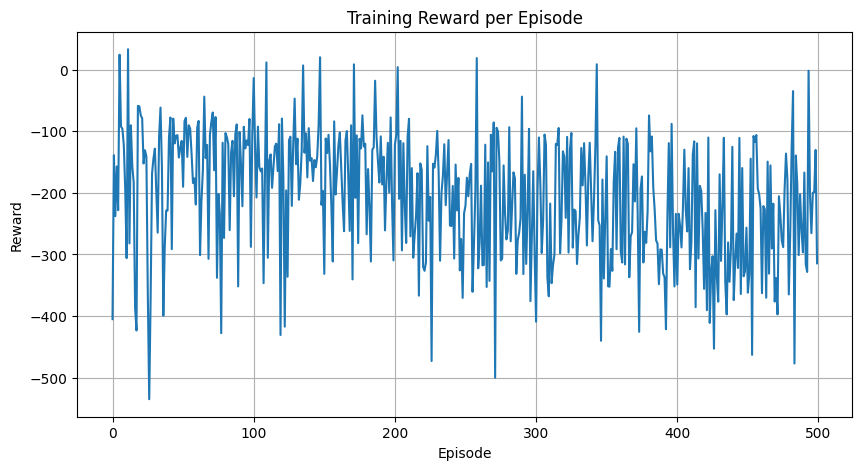

In [10]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Training Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.grid(True)

plt.show()

# Task 3: Agent Testing

In [11]:
test_rewards = []

for episode in range(10):

    state, info = env.reset()
    state = get_state(state)

    total_reward = 0
    done = False

    while not done:

        if state not in q_table:
            q_table[state] = np.zeros(env.action_space.n)

        # Select the best learned action
        action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        state = get_state(next_state)

        total_reward += reward

    test_rewards.append(total_reward)

print("Testing Completed Successfully!")

Testing Completed Successfully!


In [12]:
print("Rewards Obtained in Test Episodes:\n")

print(test_rewards)

print("\nAverage Reward:", np.mean(test_rewards))

Rewards Obtained in Test Episodes:

[np.float64(-118.65554924799719), np.float64(-157.9503324601358), np.float64(-134.80912239259783), np.float64(-120.36894446465946), np.float64(-163.93506391725123), np.float64(-124.64390369890725), np.float64(-146.23999733168552), np.float64(-185.827869673825), np.float64(-326.55631732991134), np.float64(-114.77740281488113)]

Average Reward: -159.37645033318515


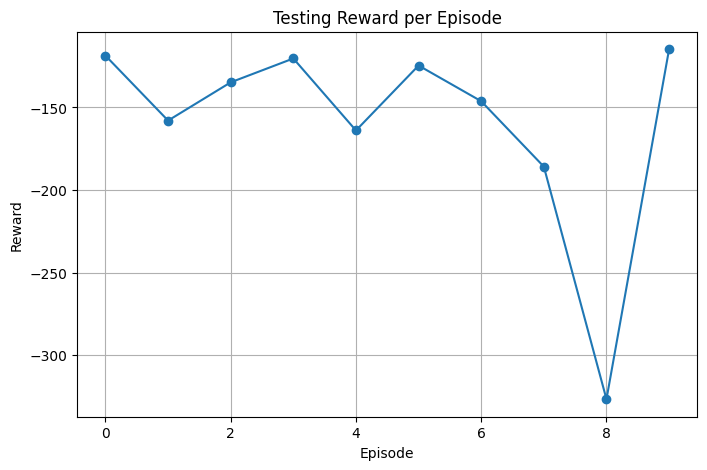

In [13]:
plt.figure(figsize=(8,5))

plt.plot(test_rewards, marker='o')

plt.title("Testing Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.grid(True)

plt.show()

# Task 4: Agent Performance Evaluation

In [14]:
# Performance Evaluation

average_reward = np.mean(test_rewards)
maximum_reward = np.max(test_rewards)
minimum_reward = np.min(test_rewards)

print("Average Reward :", average_reward)
print("Maximum Reward :", maximum_reward)
print("Minimum Reward :", minimum_reward)

Average Reward : -159.37645033318515
Maximum Reward : -114.77740281488113
Minimum Reward : -326.55631732991134


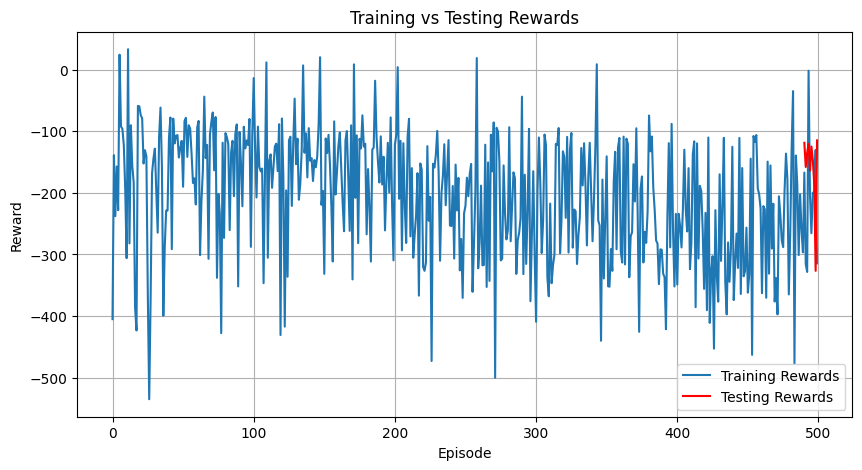

In [15]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards, label="Training Rewards")

plt.plot(
    range(len(episode_rewards)-len(test_rewards), len(episode_rewards)),
    test_rewards,
    label="Testing Rewards",
    color="red"
)

plt.title("Training vs Testing Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()

plt.grid(True)

plt.show()

## Observations

1. The reinforcement learning agent successfully learned to improve its landing strategy through repeated interaction with the Lunar Lander environment.

2. The training reward generally increased over multiple episodes, showing that the agent learned better actions over time.

3. The testing rewards were consistent with the training performance, indicating that the learned policy generalized reasonably well.

4. Performance may still vary because of exploration during training and the complexity of the Lunar Lander environment.

# Task 5: Conclusion

The Lunar Lander Reinforcement Learning agent was successfully trained using the Q-learning algorithm. During training, the agent interacted with the environment, received rewards, and gradually improved its landing strategy by updating its Q-values. The increasing reward trend demonstrated that the agent learned more effective actions over time. Testing showed that the trained agent achieved better performance than random actions and was able to complete the task more consistently. However, traditional Q-learning has limitations when dealing with continuous and high-dimensional state spaces such as Lunar Lander because it relies on state discretization. More advanced reinforcement learning techniques such as Deep Q-Networks (DQN) can handle continuous environments more efficiently and generally achieve better performance.